# Sentiment — full bake-off

Benchmarks every **regime x language x model x arm** combination on **dev**, then
picks a winner and saves its predictions.

Headline metric: **`negative_f1`** (F1 on the Negative class).

**Why not accuracy.** 95.5% of tickets are Neutral, so a model that never predicts Negative scores 0.955 and catches nobody. Section 4 plots this directly: across the whole sweep, accuracy and Negative F1 are close to uncorrelated.

Test stays sealed. Nothing in this notebook touches it.

In [1]:
import sys, time
from pathlib import Path

REPO = Path.cwd()
while not (REPO / "ml" / "swiftbench").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml"))

import pandas as pd
import matplotlib.pyplot as plt

import swiftbench as sb

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)

AUTHOR = ""

manifest = sb.splits.ensure()
print("split sha:", manifest["sha"], manifest["counts"])
print("models:", sb.models.NAMES)
print("arms:  ", sb.imbalance.ARMS)
print("regimes:", list(sb.train_classical.REGIMES))

split sha: e7b5934392cd {'train': 8500, 'dev': 1498, 'test': 3079}
models: ['tfidf-logreg', 'tfidf-svm', 'tfidf-sgd', 'tfidf-cnb']
arms:   ['none', 'class_weight', 'ros']
regimes: ['mono', 'multi', 'zeroshot-en']


## The three training regimes

This is the deployment question, not just a hyperparameter. Do we ship one
multilingual model or five monolingual ones?

| regime | trains on | answers |
|---|---|---|
| `mono` | the evaluation language only | how good can a dedicated per-language model get? |
| `multi` | all five languages at once | does one model serve everything without losing accuracy? |
| `zeroshot-en` | English only, never the eval language | how much transfers across scripts for free? |

`zeroshot-en` is the one that says anything about a language we have not built a
dataset for. Its English row is skipped — training on English and evaluating on
English is not zero-shot.

## 1. Model-free floors

Every trained number below has to be read against these.

In [2]:
TASK = "sentiment"

floor_rows = []
for lang in sb.config.LANGUAGES:
    tr, dv = sb.splits.get([lang], "train"), sb.splits.get([lang], "dev")
    s = sb.baselines.majority(tr, dv, TASK)
    floor_rows.append({"language": lang, "model": "majority", "arm": "none",
                       "regime": "mono", **{k: v for k, v in s.items() if not k.startswith("_")}})
floor_df = pd.DataFrame(floor_rows)
display(floor_df[["language", "accuracy", "negative_f1"]].round(4))
print("Always-Neutral: ~0.955 accuracy, 0.000 negative F1.")
print("Any sentiment result quoted as accuracy is meaningless.")

,language,accuracy,negative_f1
0,english,0.9546,0.0
1,sinhala,0.9546,0.0
2,singlish,0.9546,0.0
3,tamil,0.9546,0.0
4,tamilish,0.9546,0.0


Always-Neutral: ~0.955 accuracy, 0.000 negative F1.
Any sentiment result quoted as accuracy is meaningless.


## 2. The sweep

4 models x 3 arms x 3 regimes across 5 languages. `multi` and `zeroshot-en`
fit once per (training set, model, arm) and are then evaluated against each
language, so this is far fewer fits than the grid size suggests.

Progress prints per regime. Expect several minutes — the `multi` fits train on
42,500 rows.

In [3]:
started = time.time()
sweep = sb.train_classical.sweep_regimes(task=TASK, author=AUTHOR)
print(f"\n{len(sweep)} evaluations in {time.time() - started:.0f}s")

sweep.to_csv(REPO / "ml" / "reports" / f"{TASK}_bakeoff_dev.csv", index=False)
sweep.head()

  mono         train=english                      12 fits -> 1 eval lang(s)


  mono         train=sinhala                      12 fits -> 1 eval lang(s)


  mono         train=singlish                     12 fits -> 1 eval lang(s)


  mono         train=tamil                        12 fits -> 1 eval lang(s)


  mono         train=tamilish                     12 fits -> 1 eval lang(s)


  multi        train=english+sinhala+singlish+tam 12 fits -> 5 eval lang(s)


  zeroshot-en  train=english                      12 fits -> 4 eval lang(s)

168 evaluations in 100s


,regime,language,model,arm,accuracy,macro_f1,macro_precision,macro_recall,weighted_f1,n,negative_f1,negative_precision,negative_recall,n_negative_true,n_negative_pred,headline_metric,headline,n_train,fit_seconds
0,mono,english,tfidf-logreg,none,0.959279,0.593447,0.924297,0.558474,0.944090,1498,0.207792,0.888889,0.117647,68,9,negative_f1,0.207792,8500,0.30
1,mono,english,tfidf-logreg,class_weight,0.946595,0.770711,0.719141,0.866979,0.953298,1498,0.569892,0.449153,0.779412,68,118,negative_f1,0.569892,8500,0.30
2,mono,english,tfidf-logreg,ros,0.950601,0.771782,0.728762,0.841063,0.955456,1498,0.569767,0.471154,0.720588,68,104,negative_f1,0.569767,16212,0.72
3,mono,english,tfidf-svm,none,0.963284,0.712730,0.839160,0.658618,0.956658,1498,0.444444,0.709677,0.323529,68,31,negative_f1,0.444444,8500,0.29
4,mono,english,tfidf-svm,class_weight,0.964619,0.791496,0.797923,0.785376,0.964239,1498,0.601504,0.615385,0.588235,68,65,negative_f1,0.601504,8500,0.35


## 3. Which regime wins?

Averaged over languages, models and arms — the top-level deployment answer.

In [4]:
by_regime = (sweep.groupby("regime")[["negative_f1", "accuracy", "macro_f1"]]
             .agg(["mean", "max"]).round(4))
display(by_regime)

print("\nBest single configuration per regime:")
best_per_regime = sweep.loc[sweep.groupby("regime")["negative_f1"].idxmax()]
display(best_per_regime[["regime", "language", "model", "arm", "negative_f1",
                         "accuracy", "n_train"]].round(4))

negative_f1         accuracy         macro_f1        
                   mean     max     mean     max     mean     max
regime                                                           
mono             0.4773  0.6395   0.9473  0.9653   0.7246  0.8088
multi            0.4985  0.6331   0.9457  0.9666   0.7348  0.8076
zeroshot-en      0.0847  0.3158   0.8802  0.9566   0.4989  0.6420


Best single configuration per regime:


,regime,language,model,arm,negative_f1,accuracy,n_train
26,mono,singlish,tfidf-logreg,ros,0.6395,0.9586,16212
82,multi,singlish,tfidf-svm,class_weight,0.6331,0.9660,42500
165,zeroshot-en,singlish,tfidf-cnb,ros,0.3158,0.9393,16212


## 4. Which model and which arm?

The arm usually matters more than the estimator. Check that before spending
effort on model choice.

In [5]:
print("by model (mean negative_f1 across everything):")
display(sweep.groupby("model")["negative_f1"].agg(["mean", "max"]).round(4)
        .sort_values("mean", ascending=False))

print("\nby arm:")
display(sweep.groupby("arm")[["negative_f1", "accuracy"]].mean().round(4))

print("\nmodel x arm, mono regime only:")
mono = sweep[sweep.regime == "mono"]
display(mono.pivot_table(index="model", columns="arm", values="negative_f1").round(4))

by model (mean negative_f1 across everything):


,mean,max
model,,
tfidf-svm,0.4082,0.6331
tfidf-cnb,0.3744,0.5304
tfidf-logreg,0.3566,0.6395
tfidf-sgd,0.3517,0.5802



by arm:


,negative_f1,accuracy
arm,,
class_weight,0.4061,0.9252
none,0.3171,0.9281
ros,0.3949,0.9293



model x arm, mono regime only:


arm,class_weight,none,ros
model,,,
tfidf-cnb,0.4585,0.4585,0.4318
tfidf-logreg,0.5729,0.2315,0.5899
tfidf-sgd,0.4870,0.4524,0.4290
tfidf-svm,0.5880,0.4819,0.5457


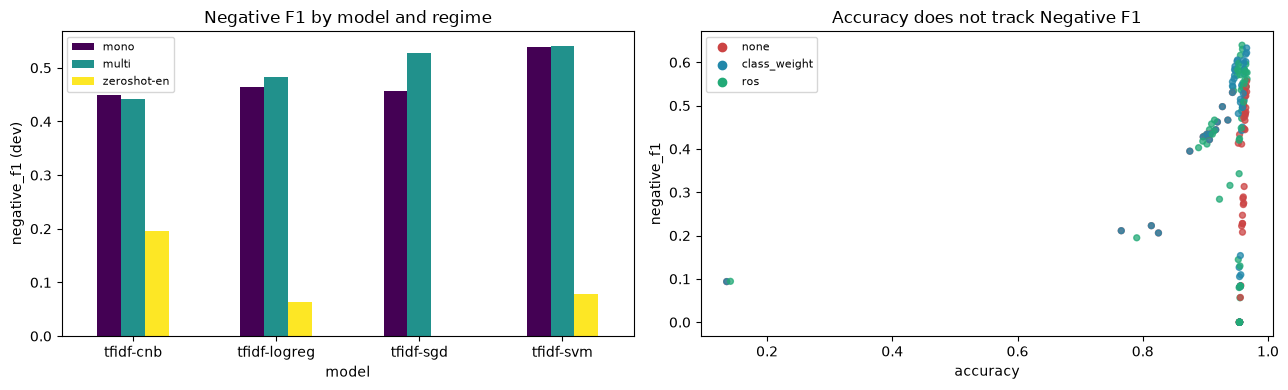

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

pv = sweep.pivot_table(index="model", columns="regime", values="negative_f1")
pv.plot(kind="bar", ax=axes[0], rot=0, colormap="viridis")
axes[0].set_title("Negative F1 by model and regime")
axes[0].set_ylabel("negative_f1 (dev)")
axes[0].legend(fontsize=8)

# the trap, again, across the whole sweep
axes[1].scatter(sweep.accuracy, sweep.negative_f1, c=sweep.arm.map(
    {"none": "#c44", "class_weight": "#28a", "ros": "#2a7"}), s=18, alpha=0.75)
axes[1].set_xlabel("accuracy")
axes[1].set_ylabel("negative_f1")
axes[1].set_title("Accuracy does not track Negative F1")
for arm, colour in [("none", "#c44"), ("class_weight", "#28a"), ("ros", "#2a7")]:
    axes[1].scatter([], [], c=colour, label=arm)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Per-language winner

What we would actually ship if we shipped per-language models.

In [7]:
winners = sweep.loc[sweep.groupby("language")["negative_f1"].idxmax()]
display(winners[["language", "regime", "model", "arm", "negative_f1",
                 "accuracy", "macro_f1"]].round(4).sort_values("negative_f1", ascending=False))

# how much does forcing a single multilingual model cost us, per language?
best_mono = sweep[sweep.regime == "mono"].groupby("language")["negative_f1"].max()
best_multi = sweep[sweep.regime == "multi"].groupby("language")["negative_f1"].max()
best_zs = sweep[sweep.regime == "zeroshot-en"].groupby("language")["negative_f1"].max()
cmp = pd.DataFrame({"mono": best_mono, "multi": best_multi, "zeroshot_en": best_zs})
cmp["multi_minus_mono"] = (cmp["multi"] - cmp["mono"]).round(4)
display(cmp.round(4))

,language,regime,model,arm,negative_f1,accuracy,macro_f1
26,singlish,mono,tfidf-logreg,ros,0.6395,0.9586,0.8088
80,english,multi,tfidf-svm,class_weight,0.6222,0.9660,0.8022
81,sinhala,multi,tfidf-svm,class_weight,0.6187,0.9646,0.8001
83,tamil,multi,tfidf-svm,class_weight,0.6040,0.9606,0.7917
52,tamilish,mono,tfidf-svm,class_weight,0.5735,0.9613,0.7766


,mono,multi,zeroshot_en,multi_minus_mono
language,,,,
english,0.6015,0.6222,NaN,0.0207
singlish,0.6395,0.6331,0.3158,-0.0064
sinhala,0.6163,0.6187,0.2061,0.0024
tamil,0.5972,0.6040,0.0944,0.0068
tamilish,0.5735,0.5714,0.2840,-0.0021


## 6. Champion — predictions and error analysis

Refit the single best configuration, save its dev predictions, and look at what
it still gets wrong.

In [8]:
champ = sweep.loc[sweep["negative_f1"].idxmax()]
train_langs = sb.train_classical.REGIMES[champ.regime](champ.language)
print(f"champion: {champ.model} / arm={champ.arm} / regime={champ.regime} "
      f"/ eval={champ.language}  ->  negative_f1 {champ['negative_f1']:.4f}")

fit = sb.train_classical.run(TASK, champ.model, train_langs, champ.language,
                             arm=champ.arm, save=False, verbose=False)
dv = sb.splits.get([champ.language], "dev")

pred_dir = REPO / "ml" / "predictions"
pred_dir.mkdir(parents=True, exist_ok=True)
out = dv[["id", "language", "text_en", "text", "category", TASK]].copy()
out[f"predicted_{TASK}"] = fit["_predictions"]
out["correct"] = out[TASK] == out[f"predicted_{TASK}"]
out.to_csv(pred_dir / f"{TASK}_champion_dev_predictions.csv", index=False)
print(f"saved {len(out)} predictions -> ml/predictions/{TASK}_champion_dev_predictions.csv")

labels, cm = sb.metrics.confusion(dv[TASK], fit["_predictions"], TASK)
display(pd.DataFrame(cm, index=[f"true {l}" for l in labels],
                     columns=[f"pred {l}" for l in labels]))

champion: tfidf-logreg / arm=ros / regime=mono / eval=singlish  ->  negative_f1 0.6395


saved 1498 predictions -> ml/predictions/sentiment_champion_dev_predictions.csv


,pred Neutral,pred Negative
true Neutral,1381,49
true Negative,13,55


In [9]:
errors = out[~out.correct]
print(f"{len(errors)} errors out of {len(out)} ({len(errors)/len(out):.1%})\n")
print("most confused pairs:")
display(errors.groupby([TASK, f"predicted_{TASK}"]).size()
        .sort_values(ascending=False).head(8).rename("count").reset_index())
print("\nsample errors:")
for _, r in errors.head(8).iterrows():
    print(f"  true={r[TASK]:8s} pred={r[f'predicted_{TASK}']:8s} [{r.category}] {str(r.text_en)[:80]}")

62 errors out of 1498 (4.1%)

most confused pairs:


,sentiment,predicted_sentiment,count
0,Neutral,Negative,49
1,Negative,Neutral,13



sample errors:
  true=Negative pred=Neutral  [card_payment_wrong_exchange_rate] Why on earth is the exchange rate so bad?   Can I get a rate closer to the actua
  true=Neutral  pred=Negative [pending_cash_withdrawal] I tried to get cash out of the ATM but it is taking too long
  true=Neutral  pred=Negative [pin_blocked] I tried my PIN too many times and now my card won't work!
  true=Neutral  pred=Negative [pin_blocked] I tried my PIN too many times
  true=Neutral  pred=Negative [pending_top_up] I tried to top up, but the funds show up as pending. I thought it was instant?
  true=Neutral  pred=Negative [pending_top_up] Help, I don't see my money i just added.
  true=Negative pred=Neutral  [pending_top_up] Is there something wrong with my top up I did an hour ago? it's still pending. I
  true=Neutral  pred=Negative [cancel_transfer] I need urgent help. I realize I sent my payment to the wrong account number. I m


## 7. Read-out

- Floor (always-Neutral): accuracy 0.955, negative-F1 **0.000**
- Champion configuration and its Negative F1: see above
- Regime verdict: see section 3

The number that decides whether an encoder is worth fine-tuning is the champion's
**Negative recall** — how many angry customers still get auto-replied to. Carry
it into `99_model_selection.ipynb`.